# Phase 5: walk-forward validation and the GRU / CNN-LSTM comparison

**Status:** Phase 5, executed report. Loads committed artifacts only (`results/*.json*`, `DECISIONS.md`, registered config, committed code). Trains no model and runs no walk-forward evaluation.

## Table of contents
1. [Question and registered design](#1.-Question-and-registered-design)
2. [Fold scheme](#2.-Fold-scheme)
3. [Leakage controls](#3.-Leakage-controls)
4. [Models and configurations](#4.-Models-and-configurations)
5. [Results](#5.-Results)
6. [What the result shows and does not show](#6.-What-the-result-shows-and-does-not-show)
7. [Engineering record](#7.-Engineering-record)
8. [Reproducing this run and what comes next](#8.-Reproducing-this-run-and-what-comes-next)

## Prerequisites
- The raw dataset present at `data/raw/energy_data_set.csv`.
- `pip install -r requirements-dev.txt`

In [1]:
%matplotlib inline
import json
import re
import subprocess
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import Markdown, display

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

REQUIRED_FILES = [
    ROOT / "results" / "walk_forward_records.jsonl",
    ROOT / "results" / "walk_forward_summary.json",
    ROOT / "DECISIONS.md",
    ROOT / "data" / "raw" / "energy_data_set.csv",
]
for _p in REQUIRED_FILES:
    assert _p.exists(), f"required file missing: {_p.relative_to(ROOT)}"

from config.features import (
    BASELINE_CONTEXT_LAGS,
    FEATURE_COLUMNS,
    SCALED_COLUMNS,
    SPLIT_VAL_END,
    TARGET_HORIZONS,
)
from config.paths import RAW_DATA_PATH
from config.walk_forward import (
    BETTER_MARGIN,
    EVAL_DAYS,
    FIRST_EVAL_START,
    FREQ_MINUTES,
    N_FOLDS,
    NEURAL_SEEDS,
    WORSE_MARGIN,
)
from src.evaluation.fold_data import build_fold_datasets
from src.evaluation.folds import make_folds
from src.evaluation.walk_forward import FoldRunRecord
from src.evaluation.walk_forward_models import deterministic_factories, seeded_factories
from src.evaluation.walk_forward_summary import summarize_walk_forward
from src.features.build_features import build_features
from src.pipeline import run_pipeline

DECISIONS_TEXT = (ROOT / "DECISIONS.md").read_text()

PALETTE = {
    "train": "#4C78A8",
    "evaluation": "#F58518",
    "test": "#9D9D9D",
    "lstm": "#1B9E77",
    "gru": "#D95F02",
    "cnn_lstm": "#7570B3",
    "reference": "#6E6E6E",
    "reference_light": "#A6A6A6",
}

plt.rcParams.update({
    "figure.dpi": 150,
    "savefig.dpi": 150,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.grid": True,
    "grid.alpha": 0.3,
    "font.size": 10,
})

IMG_DIR = ROOT / "docs" / "img"
IMG_DIR.mkdir(parents=True, exist_ok=True)

print("setup ok")

setup ok


## 1. Question and registered design

The registered decisions behind the Phase 5 walk-forward comparison, as pre-registered before any fold result existed (`DECISIONS.md`, "Phase 5: walk-forward comparison rule (pre-registration)"). Part 1 of 2.

| decision | choice | alternative considered | reason |
|---|---|---|---|
| Window | expanding, 8 folds of 7 days from 2016-03-01 | sliding window | production retrains on all data; discarding old data adds an unestablished assumption (student) |
| Horizon | h=6 (1 hour) only | also h=1 | h=6 is the registered primary; cost |
| Scaling | per-fold train-only scaler composed from fit_scaler and transform_with_scaler | reuse the global-train scaler | the global scaler saw the evaluation days of folds 1 to 6 (quantified in section 3) |
| Label purge | last 6 train labels masked per fold with mask_ineligible_labels | drop the rows | features stay valid history; the labels point into the evaluation window |
| References | linear_regression and random_forest, both fixed | a "best classical" chosen afterwards | avoids a post-hoc reference choice |
| Rule | mean of the 8 per-fold ratios per seed; better if <= 0.99 and worse if >= 1.01 on both MAE and RMSE for every seed | one metric, median or worst fold | one favourable metric or seed must not decide (student) |

### 1. Question and registered design (continued)

Part 2 of 2.

| decision | choice | alternative considered | reason |
|---|---|---|---|
| Neural configs | the LSTM's registered configuration (50 epochs, Huber delta 40) reused for GRU and CNN-LSTM | per-fold or nested tuning | out of scope; one-sided tuning advantage disclosed |
| CNN-LSTM details | Conv1d 16 to 32 channels, kernel 3, padding 1, ReLU, then LSTM 32 to 64 | padding 0 or another activation | no look-ahead either way; padding 1 preserves L=18; fixed before any fold ran |
| Shared code | SequenceForecaster (template method, explicit Linear head contract) | three copies | identical RNG order and windowing; LSTM golden bit-identical after the refactor |
| Tier 2 | folds won, worst fold, seed spread and folds 1 to 6 sensitivity defined before results | define after | avoids post-hoc metric choice |
| Governance | pre-run record, launch gate (clean tree, HEAD equals remote), no code change during the run, write-once results | ad hoc | the provenance names the commit; no overwrites |
| Test partition | not used in Phase 5; test evaluations stay at six | test inside folds | the folds end on 2016-04-26 |

In [2]:
with open(ROOT / "results" / "walk_forward_summary.json") as f:
    summary_doc = json.load(f)
provenance = summary_doc["provenance"]
summary = summary_doc["summary"]

records = []
with open(ROOT / "results" / "walk_forward_records.jsonl") as f:
    for line in f:
        line = line.strip()
        if line:
            records.append(json.loads(line))

prov_table = pd.DataFrame([{
    "field": k,
    "value": provenance[k],
} for k in ["git_commit_sha", "git_dirty", "torch_version", "numpy_version",
            "start_time_utc", "horizon", "seeds", "folds", "models"]])

assert provenance["git_dirty"] is False
assert len(records) == 104
assert summary["n_records"] == 104

sha_pattern = re.compile(
    r"sha256 results/walk_forward_records\.jsonl:\s*([0-9a-f]{64}).*?"
    r"sha256 results/walk_forward_summary\.json:\s*([0-9a-f]{64})",
    re.DOTALL,
)
_m = sha_pattern.search(DECISIONS_TEXT)
assert _m is not None, "sha256 lines not found in DECISIONS.md"
decided_records_sha, decided_summary_sha = _m.group(1), _m.group(2)

import hashlib

def _sha256(path):
    h = hashlib.sha256()
    with open(path, "rb") as fh:
        for chunk in iter(lambda: fh.read(1 << 16), b""):
            h.update(chunk)
    return h.hexdigest()

actual_records_sha = _sha256(ROOT / "results" / "walk_forward_records.jsonl")
actual_summary_sha = _sha256(ROOT / "results" / "walk_forward_summary.json")

assert decided_records_sha == actual_records_sha, (decided_records_sha, actual_records_sha)
assert decided_summary_sha == actual_summary_sha, (decided_summary_sha, actual_summary_sha)

prov_table

,field,value
0,git_commit_sha,4cc00f78d2b5e07499983a860e36d4b760f86858
1,git_dirty,False
2,torch_version,2.14.0+cpu
3,numpy_version,2.5.3
4,start_time_utc,2026-09-24T15:49:18.706067+00:00
5,horizon,6
6,seeds,"[42, 43, 44]"
7,folds,8
8,models,"[naive_persistence, naive_seasonal, linear_reg..."


## 2. Fold scheme

Eight expanding-window folds, each covering a 7-day evaluation window, are generated by the registered `make_folds` from the same feature timestamps the run used. Figure 1 shows the resulting train/evaluation split per fold against the held-out validation and test partitions.

In [3]:
df_raw = pd.read_csv(RAW_DATA_PATH, parse_dates=["date"])
df_features = build_features(df_raw, target_horizons=TARGET_HORIZONS)
result = run_pipeline(df_raw)

timestamps = pd.DatetimeIndex(
    pd.concat([result.train_t6["date"], result.val_t6["date"], result.test_t6["date"]])
    .sort_values()
    .reset_index(drop=True)
)

specs = make_folds(
    timestamps,
    first_eval_start=FIRST_EVAL_START,
    n_folds=N_FOLDS,
    eval_days=EVAL_DAYS,
    freq_minutes=FREQ_MINUTES,
    holdout_start=SPLIT_VAL_END,
)

fold_table = pd.DataFrame([{
    "fold": s.fold,
    "train_start": s.train_start,
    "eval_start": s.eval_start,
    "eval_end": s.eval_end,
    "n_train": s.n_train,
    "n_eval": s.n_eval,
} for s in specs])

stored_fold_table = pd.DataFrame(provenance["fold_table"]).sort_values("fold").reset_index(drop=True)

for col in ["eval_start", "eval_end"]:
    assert (pd.to_datetime(fold_table[col]).values == pd.to_datetime(stored_fold_table[col]).values).all()
assert (fold_table["n_train"].values == stored_fold_table["n_train"].values).all()
assert (fold_table["n_eval"].values == stored_fold_table["n_eval"].values).all()

fold_table[["fold", "eval_start", "eval_end", "n_train", "n_eval"]]

,fold,eval_start,eval_end,n_train,n_eval
0,1,2016-03-01,2016-03-08,6954,1008
1,2,2016-03-08,2016-03-15,7962,1008
2,3,2016-03-15,2016-03-22,8970,1008
3,4,2016-03-22,2016-03-29,9978,1008
4,5,2016-03-29,2016-04-05,10986,1008
5,6,2016-04-05,2016-04-12,11994,1008
6,7,2016-04-12,2016-04-19,13002,1008
7,8,2016-04-19,2016-04-26,14010,1008


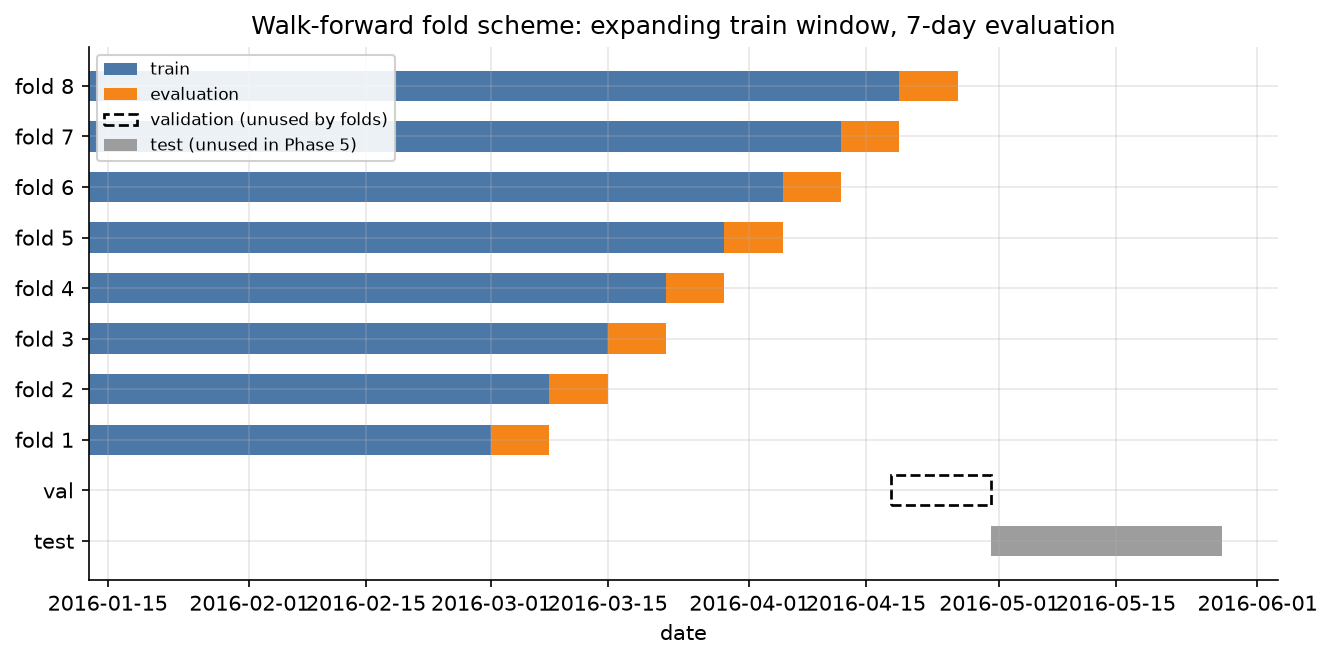

saved docs/img/walk_forward_folds.png


In [4]:
val_start = timestamps[result.train_t6.shape[0]]
val_end_ts = pd.Timestamp(SPLIT_VAL_END)
test_end_ts = timestamps[-1]

fig, ax = plt.subplots(figsize=(9, 4.5))
for s in specs:
    y = s.fold
    ax.barh(y, (s.eval_start - s.train_start), left=s.train_start, height=0.6,
            color=PALETTE["train"], label="train" if y == 1 else None)
    ax.barh(y, (s.eval_end - s.eval_start), left=s.eval_start, height=0.6,
            color=PALETTE["evaluation"], label="evaluation" if y == 1 else None)

ax.barh(0, (val_end_ts - val_start), left=val_start, height=0.6,
        facecolor="none", edgecolor="black", linestyle="--", linewidth=1.3,
        label="validation (unused by folds)")
ax.barh(-1, (test_end_ts - val_end_ts), left=val_end_ts, height=0.6,
        color=PALETTE["test"], label="test (unused in Phase 5)")

ax.set_yticks([-1, 0, *range(1, N_FOLDS + 1)])
ax.set_yticklabels(["test", "val", *[f"fold {k}" for k in range(1, N_FOLDS + 1)]])
ax.set_xlabel("date")
ax.set_title("Walk-forward fold scheme: expanding train window, 7-day evaluation")
ax.legend(loc="upper left", fontsize=8, framealpha=0.9)
fig.tight_layout()
fig.savefig(IMG_DIR / "walk_forward_folds.png", dpi=150)
plt.show()
plt.close(fig)
print("saved docs/img/walk_forward_folds.png")

## 3. Leakage controls

- **Per-fold train-only scaler.** Each fold fits a fresh `StandardScaler` on that fold's training rows only (`fit_scaler` + `transform_with_scaler`), rather than reusing the pipeline's global-train scaler.
- **Label purge.** The last 6 training labels of each fold are masked to `NaN` by `mask_ineligible_labels`, since their horizon points into the evaluation window; the rows themselves are kept so later windows still have valid feature history.
- **Holdout guard.** `make_folds` raises if any fold's evaluation window would extend past `holdout_start` (the validation boundary), so no fold can silently reach into held-out data.
- **Causality tripwire tests.** `tests/test_fold_data.py` and `tests/test_walk_forward.py` assert the fold/purge invariants directly.
- **LSTM golden.** The `SequenceForecaster` refactor that GRU and CNN-LSTM are built on was checked bit-identical against a frozen LSTM golden fixture before any fold ran.

In [5]:
global_scaler = result.scaler
global_mean = pd.Series(global_scaler.mean_, index=SCALED_COLUMNS)
global_std = pd.Series(global_scaler.scale_, index=SCALED_COLUMNS)

scaler_rows = []
for spec in specs:
    fd = build_fold_datasets(df_features, spec, 6)
    fold_mean = pd.Series(fd.scaler.mean_, index=SCALED_COLUMNS)
    fold_scale = pd.Series(fd.scaler.scale_, index=SCALED_COLUMNS)

    mean_diff_in_global_std = ((fold_mean - global_mean) / global_std).abs()
    scale_ratio = fold_scale / global_std

    assert len(fd.eval_df) == 1008
    n_ineligible = fd.train_df["target_t6"].isna().sum()
    assert n_ineligible == 6
    assert fd.train_df["target_t6"].isna().iloc[-6:].all()
    assert not fd.train_df["target_t6"].isna().iloc[:-6].any()

    scaler_rows.append({
        "fold": spec.fold,
        "max_abs_mean_diff_std_units": mean_diff_in_global_std.max(),
        "min_scale_ratio": scale_ratio.min(),
        "max_scale_ratio": scale_ratio.max(),
    })

scaler_drift_table = pd.DataFrame(scaler_rows)
print("descriptive: per-fold scaler drift relative to the global-train scaler")
scaler_drift_table

descriptive: per-fold scaler drift relative to the global-train scaler


,fold,max_abs_mean_diff_std_units,min_scale_ratio,max_scale_ratio
0,1,0.072861,1.016323,1.039574
1,2,0.059773,1.006565,1.026279
2,3,0.045047,0.999189,1.017512
3,4,0.041847,0.995881,1.015908
4,5,0.031627,0.998888,1.010228
5,6,0.018005,0.982479,1.000728
6,7,0.010435,0.992793,0.999211
7,8,0.003847,0.996921,0.999867


## 4. Models and configurations

Seven models are evaluated at every fold: two naive baselines, two classical references, and three neural sequence models sharing one registered configuration.

| name | family | configuration | seeds |
|---|---|---|---|
| naive_persistence | naive baseline | holds Appliances[t] flat | none (deterministic) |
| naive_seasonal | naive baseline | same time, one seasonal period ago | none (deterministic) |
| linear_regression | classical reference | sklearn LinearRegression, default | none (deterministic) |
| random_forest | classical reference | sklearn RandomForestRegressor, default | none (deterministic) |
| lstm | neural | 50 epochs, Huber delta 40, L=18, hidden 64 | 42, 43, 44 |
| gru | neural | 50 epochs, Huber delta 40, L=18, hidden 64 | 42, 43, 44 |
| cnn_lstm | neural | 50 epochs, Huber delta 40, Conv1d 16-32ch k3 p1 ReLU, then LSTM 32-64 | 42, 43, 44 |

In [6]:
seeded = seeded_factories()
deterministic = deterministic_factories(6)

EXPECTED_PARAMS = {"lstm": 21057, "gru": 15809, "cnn_lstm": 26721}

param_rows = []
for name, factory in seeded.items():
    model = factory(NEURAL_SEEDS[0])
    net = model._build_network(len(model.required_columns))
    n_params = sum(p.numel() for p in net.parameters())
    assert n_params == EXPECTED_PARAMS[name], (name, n_params, EXPECTED_PARAMS[name])
    param_rows.append({"model": name, "n_params": n_params, "registered_params": model.params})

for name, factory in deterministic.items():
    model = factory()
    param_rows.append({"model": name, "n_params": None, "registered_params": model.params})

neural_param_table = pd.DataFrame(param_rows)
neural_param_table

,model,n_params,registered_params
0,lstm,21057.0,"{'L': 18, 'hidden_size': 64, 'num_layers': 1, ..."
1,gru,15809.0,"{'L': 18, 'hidden_size': 64, 'num_layers': 1, ..."
2,cnn_lstm,26721.0,"{'L': 18, 'hidden_size': 64, 'num_layers': 1, ..."
3,naive_persistence,NaN,{}
4,naive_seasonal,NaN,"{'horizon': 6, 'seasonal_period': 144}"
5,linear_regression,NaN,{'fit_intercept': True}
6,random_forest,NaN,"{'n_estimators': 100, 'max_depth': None, 'rand..."


## 5. Results

**Registered rule** (recomputed independently below, not typed by hand):
- **shown better** — every seed's mean MAE ratio AND mean RMSE ratio <= 0.99
- **shown worse** — every seed's mean MAE ratio AND mean RMSE ratio >= 1.01
- **not shown** — anything else, including a mixed result across the two metrics

In [7]:
fold_record_objs = [FoldRunRecord(**line) for line in records]
recomputed = summarize_walk_forward(fold_record_objs, neural_models=["lstm", "gru", "cnn_lstm"])

recomputed_rt = json.loads(json.dumps(recomputed))
stored_rt = json.loads(json.dumps(summary))
assert recomputed_rt == stored_rt

verdict_rows = []
for neural_model, refs in summary["verdicts"].items():
    for reference, v in refs.items():
        verdict_rows.append({
            "model": neural_model,
            "reference": reference,
            "verdict": v["verdict"],
            "mean_mae_ratio_by_seed": [round(x, 4) for x in v["mean_mae_ratios"]],
            "mean_rmse_ratio_by_seed": [round(x, 4) for x in v["mean_rmse_ratios"]],
        })
verdict_table = pd.DataFrame(verdict_rows)

assert (verdict_table["verdict"] == "not shown").all()
for _, v in verdict_table.iterrows():
    assert all(x <= BETTER_MARGIN for x in v["mean_mae_ratio_by_seed"])
    assert all(x >= WORSE_MARGIN for x in v["mean_rmse_ratio_by_seed"])

verdict_table

,model,reference,verdict,mean_mae_ratio_by_seed,mean_rmse_ratio_by_seed
0,cnn_lstm,linear_regression,not shown,"[0.9268, 0.9222, 0.9436]","[1.0306, 1.0284, 1.0457]"
1,cnn_lstm,random_forest,not shown,"[0.8973, 0.8933, 0.9135]","[1.0269, 1.0245, 1.0421]"
2,gru,linear_regression,not shown,"[0.9135, 0.9184, 0.896]","[1.0324, 1.0445, 1.0312]"
3,gru,random_forest,not shown,"[0.884, 0.889, 0.8676]","[1.0282, 1.0404, 1.0272]"
4,lstm,linear_regression,not shown,"[0.9187, 0.9145, 0.9264]","[1.0448, 1.023, 1.0442]"
5,lstm,random_forest,not shown,"[0.8897, 0.8859, 0.8973]","[1.0414, 1.0199, 1.0405]"


In [8]:
means_rows = []
for model, m in summary["per_model_means"].items():
    means_rows.append({"model": model, "mean_mae": m["mean_mae"], "mean_rmse": m["mean_rmse"], "mean_mape": m["mean_mape"]})
means_table = pd.DataFrame(means_rows).set_index("model")

means_display = means_table.copy()
for col in means_table.columns:
    best = means_table[col].idxmin()
    means_display[col] = means_table[col].map(lambda v: f"{v:.2f}")
    means_display.loc[best, col] = means_display.loc[best, col] + " *"

lowest_rmse_model = means_table["mean_rmse"].idxmin()
assert lowest_rmse_model == "linear_regression"

neural_models = ["lstm", "gru", "cnn_lstm"]
lowest_mae_three = set(means_table["mean_mae"].sort_values().index[:3])
lowest_mape_three = set(means_table["mean_mape"].sort_values().index[:3])
assert lowest_mae_three == set(neural_models)
assert lowest_mape_three == set(neural_models)

naive_models = ["naive_persistence", "naive_seasonal"]
learned_models = ["linear_regression", "random_forest", *neural_models]
for lm in learned_models:
    for nm in naive_models:
        assert means_table.loc[lm, "mean_mae"] < means_table.loc[nm, "mean_mae"]
        assert means_table.loc[lm, "mean_rmse"] < means_table.loc[nm, "mean_rmse"]

means_display

,mean_mae,mean_rmse,mean_mape
model,,,
cnn_lstm,42.88,90.59,36.88
gru,41.85 *,90.50,34.92 *
linear_regression,46.06,87.40 *,46.90
lstm,42.37,90.73,35.89
naive_persistence,53.73,113.68,47.25
naive_seasonal,63.44,129.23,63.36
random_forest,47.46,87.71,49.75


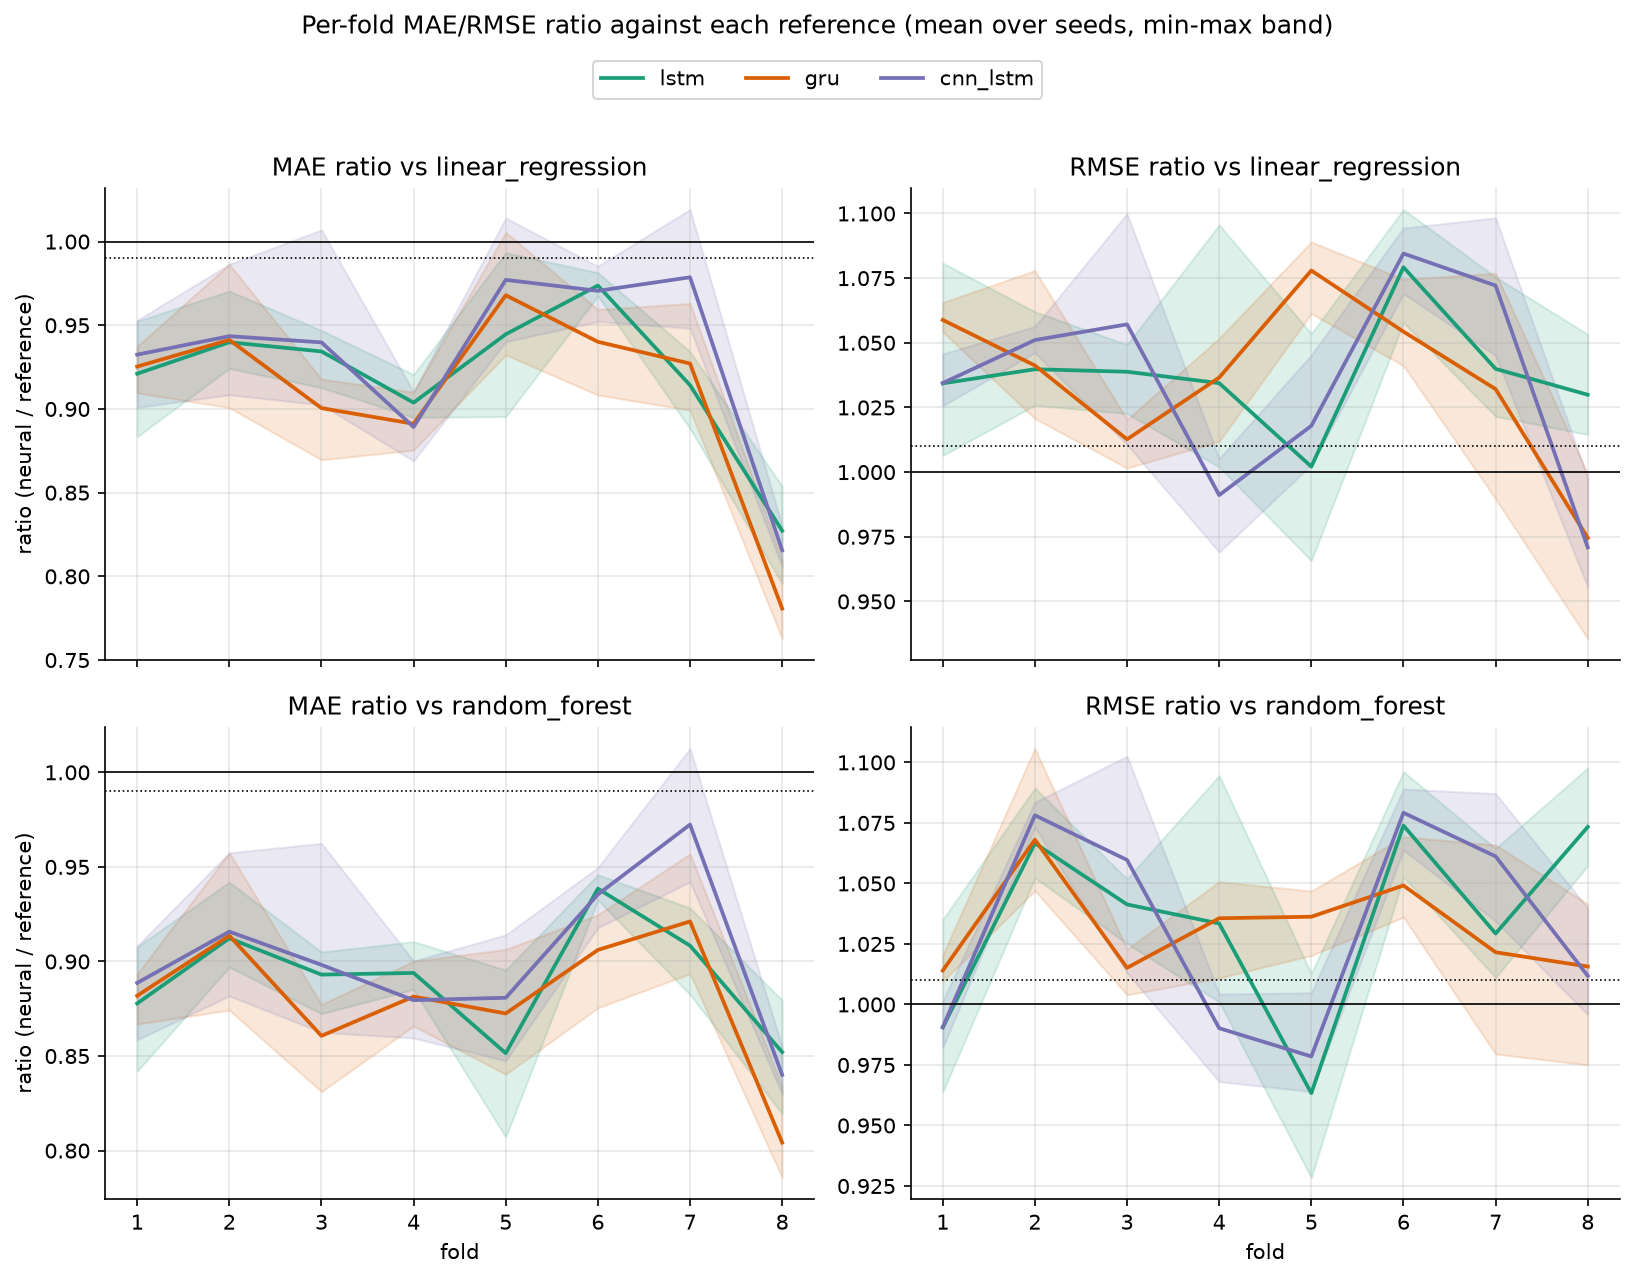

saved docs/img/walk_forward_ratios.png


In [9]:
fig, axes = plt.subplots(2, 2, figsize=(11, 8), sharex=True)
references = ["linear_regression", "random_forest"]
metrics = ["mae", "rmse"]

for i, reference in enumerate(references):
    for j, metric in enumerate(metrics):
        ax = axes[i, j]
        margin = BETTER_MARGIN if metric == "mae" else WORSE_MARGIN
        for model in neural_models:
            ratios_by_seed = []
            for seed in NEURAL_SEEDS:
                per_fold = []
                for fold in range(1, N_FOLDS + 1):
                    num = next(r for r in records if r["fold"] == fold and r["model"] == model and r["seed"] == seed)[metric]
                    den = next(r for r in records if r["fold"] == fold and r["model"] == reference and r["seed"] is None)[metric]
                    per_fold.append(num / den)
                ratios_by_seed.append(per_fold)
            arr = np.array(ratios_by_seed)
            folds_x = np.arange(1, N_FOLDS + 1)
            mean_line = arr.mean(axis=0)
            ax.plot(folds_x, mean_line, color=PALETTE[model], label=model, linewidth=1.8)
            ax.fill_between(folds_x, arr.min(axis=0), arr.max(axis=0), color=PALETTE[model], alpha=0.15)
        ax.axhline(1.0, color="black", linewidth=0.8)
        ax.axhline(margin, color="black", linewidth=0.8, linestyle=":")
        ax.set_title(f"{metric.upper()} ratio vs {reference}")
        if i == 1:
            ax.set_xlabel("fold")
        if j == 0:
            ax.set_ylabel("ratio (neural / reference)")

handles, labels = axes[0, 0].get_legend_handles_labels()
fig.legend(handles, labels, loc="upper center", ncol=3, bbox_to_anchor=(0.5, 1.03))
fig.suptitle("Per-fold MAE/RMSE ratio against each reference (mean over seeds, min-max band)", y=1.06)
fig.tight_layout()
fig.savefig(IMG_DIR / "walk_forward_ratios.png", dpi=150, bbox_inches="tight")
plt.show()
plt.close(fig)
print("saved docs/img/walk_forward_ratios.png")

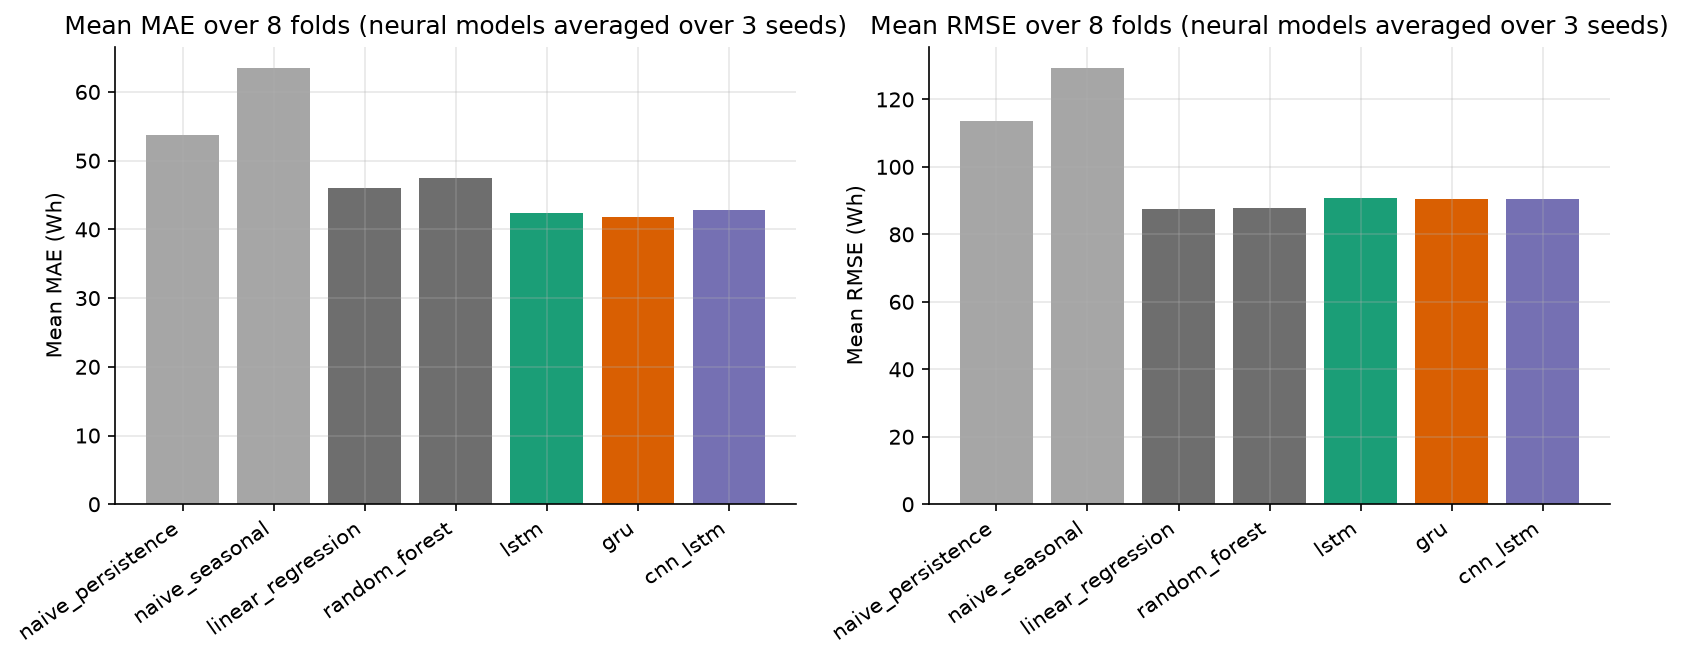

saved docs/img/walk_forward_means.png


In [10]:
model_order = ["naive_persistence", "naive_seasonal", "linear_regression", "random_forest", "lstm", "gru", "cnn_lstm"]
bar_colors = [
    PALETTE["reference_light"], PALETTE["reference_light"],
    PALETTE["reference"], PALETTE["reference"],
    PALETTE["lstm"], PALETTE["gru"], PALETTE["cnn_lstm"],
]

fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
x = np.arange(len(model_order))
for ax, metric, title, unit in zip(
    axes, ["mean_mae", "mean_rmse"], ["Mean MAE", "Mean RMSE"], ["Wh", "Wh"]
):
    values = [summary["per_model_means"][m][metric] for m in model_order]
    ax.bar(x, values, color=bar_colors)
    ax.set_xticks(x)
    ax.set_xticklabels(model_order, rotation=35, ha="right")
    ax.set_ylabel(f"{title} ({unit})")
    ax.set_title(f"{title} over 8 folds (neural models averaged over 3 seeds)")

fig.tight_layout()
fig.savefig(IMG_DIR / "walk_forward_means.png", dpi=150)
plt.show()
plt.close(fig)
print("saved docs/img/walk_forward_means.png")

In [11]:
tier2_rows = []
for model in neural_models:
    for reference in references:
        v = summary["verdicts"][model][reference]
        eight_fold_class = (
            all(x <= BETTER_MARGIN for x in v["mean_mae_ratios"]),
            all(x >= WORSE_MARGIN for x in v["mean_rmse_ratios"]),
        )
        sens = v["sensitivity_folds_1_to_6"]
        sens_class = (
            all(x <= BETTER_MARGIN for x in sens["mean_mae_ratios"]),
            all(x >= WORSE_MARGIN for x in sens["mean_rmse_ratios"]),
        )
        assert sens_class == eight_fold_class, (model, reference, sens_class, eight_fold_class)
        tier2_rows.append({
            "model": model,
            "reference": reference,
            "folds_won_mae": v["folds_won_mae"],
            "folds_won_rmse": v["folds_won_rmse"],
            "worst_fold_mae_ratio": [round(x, 4) for x in v["worst_fold_mae_ratio"]],
            "worst_fold_rmse_ratio": [round(x, 4) for x in v["worst_fold_rmse_ratio"]],
            "seed_spread_mae": round(v["seed_spread_mae"], 4),
            "seed_spread_rmse": round(v["seed_spread_rmse"], 4),
            "folds_1_6_sensitivity_matches_8_fold": sens_class == eight_fold_class,
        })
tier2_table = pd.DataFrame(tier2_rows)
tier2_table

,model,reference,folds_won_mae,folds_won_rmse,worst_fold_mae_ratio,worst_fold_rmse_ratio,seed_spread_mae,seed_spread_rmse,folds_1_6_sensitivity_matches_8_fold
0,lstm,linear_regression,"[8, 8, 8]","[0, 1, 1]","[0.9934, 0.9704, 0.9814]","[1.0956, 1.062, 1.1016]",0.0061,0.0124,True
1,lstm,random_forest,"[8, 8, 8]","[1, 2, 1]","[0.9372, 0.9419, 0.9459]","[1.0977, 1.0894, 1.0962]",0.0058,0.0122,True
2,gru,linear_regression,"[8, 7, 8]","[2, 1, 1]","[0.9864, 1.0055, 0.9367]","[1.0835, 1.089, 1.0613]",0.0118,0.0074,True
3,gru,random_forest,"[8, 8, 8]","[2, 0, 0]","[0.9575, 0.9569, 0.9131]","[1.1057, 1.0659, 1.047]",0.0112,0.0073,True
4,cnn_lstm,linear_regression,"[8, 7, 6]","[1, 2, 2]","[0.9853, 1.0192, 1.014]","[1.0902, 1.0983, 1.0999]",0.0113,0.0094,True
5,cnn_lstm,random_forest,"[8, 7, 8]","[3, 3, 2]","[0.9624, 1.0126, 0.9625]","[1.0848, 1.089, 1.1026]",0.0107,0.0095,True


## 6. What the result shows and does not show

**Shows**
- All six (neural model, reference) pairs are verdict "not shown" under the registered rule (section 5).
- Mean MAE improves for all three neural models relative to both references, while mean RMSE does not (section 5, C13).
- linear_regression has the lowest mean RMSE of the seven models (C13).
- Every learned model (linear_regression, random_forest, lstm, gru, cnn_lstm) beats both naive baselines on mean MAE and mean RMSE (asserted in C13).

**Does not show**
- Superiority or inferiority of any model under the registered rule.
- A ranking among the three neural models.
- A cause of the MAE/RMSE split — one untested hypothesis (AI mentor, `DECISIONS.md`): the Huber loss (delta 40 Wh) downweights large errors, which would favour MAE over RMSE.
- Generalisation beyond one house and one 138-day stretch.

**Registered limits**
- Only the LSTM had a validation grid; GRU and CNN-LSTM reuse its configuration untuned, so any tuning advantage is one-sided.
- Folds 7 and 8 overlap the validation period that the LSTM configuration was selected on.
- The folds are not independent or fresh data; later folds train on more history.
- The test partition was not used in Phase 5; test evaluations stay at six.

In [12]:
student_pattern = re.compile(
    r"### Student reading \(student\), written after seeing the results\n(.*?)\n### ",
    re.DOTALL,
)
_m = student_pattern.search(DECISIONS_TEXT)
assert _m is not None and _m.group(1).strip(), "student reading section not found or empty"
student_reading_md = _m.group(1).strip()
display(Markdown(student_reading_md))

The six "not shown" verdicts mean that none of the three deep models demonstrated the required improvement over the references under the pre-registered rule: the condition had to hold for both MAE and RMSE, so being better on one metric was insufficient. In particular, the aggregate results show that GRU has lower MAE than both classical references, but its RMSE remains higher than the linear-regression reference, so that split prevents a "shown better" verdict. "Not shown" therefore does not mean that the deep models are worse; it means the evidence did not satisfy the predefined criterion for demonstrating superiority.

I registered both MAE and RMSE because they capture different aspects of forecasting error, and the actual results demonstrate why requiring both matters: a model can improve average absolute error while still producing larger squared errors from some predictions. Using both prevents the verdict from being determined by whichever metric happens to favor a model.

The disclosure that matters most to me is the one-sided LSTM tuning. The LSTM configuration was selected through its validation grid, while GRU and CNN-LSTM used fixed settings rather than receiving equivalent per-model tuning, so the comparison is not a symmetric hyperparameter-optimization exercise. That limitation should be explicit when interpreting the six "not shown" results.

## 7. Engineering record

In [13]:
fit_times_pattern = re.compile(
    r"### Fit times \(from the progress log.*?\n(.*?)\n\n### ",
    re.DOTALL,
)
_m = fit_times_pattern.search(DECISIONS_TEXT)
assert _m is not None and _m.group(1).strip(), "fit times section not found or empty"
fit_times_md = _m.group(1).strip()
display(Markdown(fit_times_md))

| model | fits | mean s | min s | max s |
|---|---|---|---|---|
| naive_persistence | 8 | 0.1 | 0.0 | 0.3 |
| naive_seasonal | 8 | 0.0 | 0.0 | 0.0 |
| linear_regression | 8 | 0.0 | 0.0 | 0.1 |
| random_forest | 8 | 5.8 | 3.2 | 7.9 |
| lstm | 24 | 24.2 | 11.3 | 35.5 |
| gru | 24 | 42.1 | 25.5 | 60.1 |
| cnn_lstm | 24 | 31.5 | 19.8 | 42.0 |

Note: /tmp/wf_run.log lived outside the repository by design and was lost to an unrelated tool-classifier timeout after the run finished. These fit-time figures are the exact values that were computed live from that log immediately after the run completed (see the session transcript); they were not re-derived or estimated after the file was lost.

In [14]:
git_log = subprocess.run(
    ["git", "log", "--reverse", "--format=%h %s", "41a8ab3^..7cb321f"],
    cwd=ROOT, capture_output=True, text=True, check=True,
).stdout.strip().splitlines()
assert len(git_log) > 0

commit_rows = [line.split(" ", 1) for line in git_log]
commit_table = pd.DataFrame(commit_rows, columns=["hash", "subject"])
commit_table

,hash,subject
0,41a8ab3,docs: pre-register the Phase 5 walk-forward co...
1,083d3b5,"feat(evaluation): make_folds, pure expanding-w..."
2,444ab08,docs: record the measured Phase 5 fold table a...
3,fe5df1e,"feat(evaluation): build_fold_datasets, per-fol..."
4,4245739,feat(evaluation): pure walk-forward verdict ag...
5,e1a6cff,feat(evaluation): walk-forward runner over mod...
6,00cd079,feat(evaluation): pure walk-forward summary of...
7,f30aaca,test: freeze a small validation-only LSTM gold...
8,f15712f,refactor(models): extract SequenceForecaster f...
9,ac7a872,feat(models): GRUForecaster as a thin Sequence...


## 8. Reproducing this run and what comes next

```bash
python -m src.evaluation.walk_forward_run --out-dir <new directory>
```

The runner refuses to overwrite committed results — it appends to a fresh output directory only.

**Open items**
- MLflow logging and registration of a final model.
- The serving layer (Phase 6).
- Drift monitoring (Phase 7).

In [15]:
print("all notebook assertions passed")

all notebook assertions passed
